# Koyna Dam 

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import re

import xara

import veux

cwd = Path.cwd()
KOYNA_DIR = cwd

OUT = KOYNA_DIR / 'out' 
OUT.mkdir(parents=True, exist_ok=True)




Import constants to help track units from the {ref}`units` module.

In [2]:

from xara.units.si import (
    m,   # meter
    mm,  # millimeter
    kg,  # kilogram
    Pa,
    MPa,
    GPa,
    gravity as g
)


In [3]:
def support_nodes(model):
    return [tag for tag in model.getNodeTags() if abs(model.nodeCoord(tag)[1]) < 1.0e-9]


def upstream_face_nodes(model):
    return sorted(
        [(tag, model.nodeCoord(tag)) for tag in model.getNodeTags() if abs(model.nodeCoord(tag)[0]) < 1.0e-9],
        key=lambda item: item[1][1],
    )


def crest_node(model):
    return max(upstream_face_nodes(model), key=lambda item: (item[1][1], -item[0]))[0]


def hydrodynamic_loading(model, h_water, rho_water, thickness, gravity):
    face_nodes = upstream_face_nodes(model)
    added_masses = {}
    hydro_loads = {}

    for index, (tag, (_, y)) in enumerate(face_nodes):
        if y > h_water:
            break

        if index == 0:
            tributary = (face_nodes[index + 1][1][1] - y) / 2.0
        elif index == len(face_nodes) - 1:
            tributary = (y - face_nodes[index - 1][1][1]) / 2.0
        else:
            tributary = (face_nodes[index + 1][1][1] - face_nodes[index - 1][1][1]) / 2.0

        mass_per_area = 0.875 * rho_water * np.sqrt(h_water * (h_water - y))
        node_mass = mass_per_area * tributary * thickness
        pressure = rho_water * gravity * (h_water - y)

        added_masses[tag] = (node_mass, 0.0)
        hydro_loads[tag] = (pressure * tributary * thickness, 0.0)

    return added_masses, hydro_loads


def model_edges(model):
    edges = set()
    for ele in model.getEleTags():
        nodes = model.eleNodes(ele)
        for i, j in ((0, 1), (1, 2), (2, 3), (3, 0)):
            edges.add(tuple(sorted((nodes[i], nodes[j]))))
    return sorted(edges)


## Modeling

### Parameters

In [4]:
L_base = 70.0 * m
H_base = 66.5 * m
H_top = 36.5 * m
thickness = 1.0
h_water = 91.75 * m

nx = 14 #20
ny_base = 14 # 24
ny_top = 14

Ec = 31.027 * GPa
fc = 24.1 * MPa
ft = 2.9 * MPa
nu = 0.2
rho = 2643.0 * kg / (m ** 3)
rho_water = 1000.0 * kg / (m ** 3)
zeta = 0.03



### Mesh Generation

The element mesh is generated using the {py:meth}`Model.surface` method.

In [ ]:
model = xara.Model(ndm=2, ndf=2)

Element = "Q8"

shear_modulus = Ec / (2.0 * (1.0 + nu))
model.material('ElasticIsotropic', 1, 
               E=Ec, 
               G=shear_modulus,
               density = rho
)


# Create a section and add it to the model
section = xara.PlaneSection("PlaneStress", 
                            thickness=thickness, 
                            material=1)

model.section(section)


plane_args = {"section": section, "b": [0.0, -g*rho]}

base_surface = model.surface(
    (nx, ny_base),
    element=Element,
    args=plane_args,
    points={
        1: (0.0, 0.0),
        2: (L_base, 0.0),
        3: (19.25 * m, H_base),
        4: (0.0, H_base),
    },
)

crest_surface = model.surface(
    (nx, ny_top),
    element=Element,
    args=plane_args,
    points={
        1: (0.0, H_base),
        2: (19.25 * m, H_base),
        3: (14.8 * m, H_base + H_top),
        4: (0.0, H_base + H_top),
    },
)

for tag in support_nodes(model):
    model.fix(tag, 1, 1)


added_masses, hydro_loads = hydrodynamic_loading(model, h_water, rho_water, thickness, g)
for tag, (mx, my) in added_masses.items():
    model.mass(tag, mx, my)

crest = crest_node(model)

print(f'Nodes: {len(model.getNodeTags())}')
print(f'Elements: {len(model.getEleTags())}')
print(f'Crest node: {crest}')
print(f'Upstream water-loaded nodes: {len(hydro_loads)}')


artist = veux.create_artist(model, ndf=2)
artist.draw_nodes(size=4)
artist.draw_outlines()
artist

# veux.render(model,state=model.nodeDisp, scale=1, ndf = 2)

# model.asdict()

Nodes: 1261
Elements: 392
Crest node: 1233
Upstream water-loaded nodes: 48


## Gravity


In [6]:
model.pattern('Plain', 1,'Constant')
for tag, (fx, fy) in hydro_loads.items():
    model.load(tag, (fx, fy), pattern=1)


model.constraints('Plain')
model.numberer('RCM')
model.system('BandGeneral')
model.test('EnergyIncr', 1.0e-12, 50)
model.algorithm('Newton')
model.integrator('LoadControl', 1.0)
model.analysis('Static')

static_ok = model.analyze(1)
if static_ok != 0:
    raise RuntimeError(f'Gravity analysis failed with code {static_ok}')


print('Gravity analysis completed.')
model.loadConst(time=0.0)


crest_disp = model.nodeResponse(crest_node(model),1,'displacement')
assert(model.nodeDisp(crest_node(model),1) == crest_disp)
crest_disp


Gravity analysis completed.


0.003244099198686513

In [7]:
from xara.post import NodalStress

artist = veux.create_artist(model, canvas="gltf", ndf=2)

artist.draw_outlines()
artist.draw_outlines(state=model.nodeDisp, scale=1000)
artist.draw_surfaces(state=model.nodeDisp, scale=1000, field=NodalStress(model, "sxx"))
artist


## Eigenvalues, and Damping

In [8]:

eigenvalues = model.eigen(5)
periods = [2.0 * np.pi / np.sqrt(value) for value in eigenvalues]

omega_1 = np.sqrt(eigenvalues[0])
beta_k = 2.0 * zeta / omega_1
model.rayleigh(0.0, 0.0, 0.0, beta_k)

print('Eigen analysis completed.')
print('First five periods (s):')
for i, period in enumerate(periods, start=1):
    print(f'  Mode {i}: {period:.6e}')
print(f'Stiffness-proportional damping beta_k = {beta_k:.6e}')




Eigen analysis completed.
First five periods (s):
  Mode 1: 3.787715e-01
  Mode 2: 1.501149e-01
  Mode 3: 9.373336e-02
  Mode 4: 7.839909e-02
  Mode 5: 5.275286e-02
Stiffness-proportional damping beta_k = 3.617001e-03


Structural modes are similarly rendered using the {ref}`nodeEigenvector` method.

In [9]:
mode = 2
artist = veux.create_artist(model, ndf=2)

artist.draw_outlines()
artist.draw_outlines(state=lambda n: model.nodeEigenvector(n, mode), scale=10000)
artist

## Transient Analysis


Input duration: 10.000 s
Data time step: 0.010 s


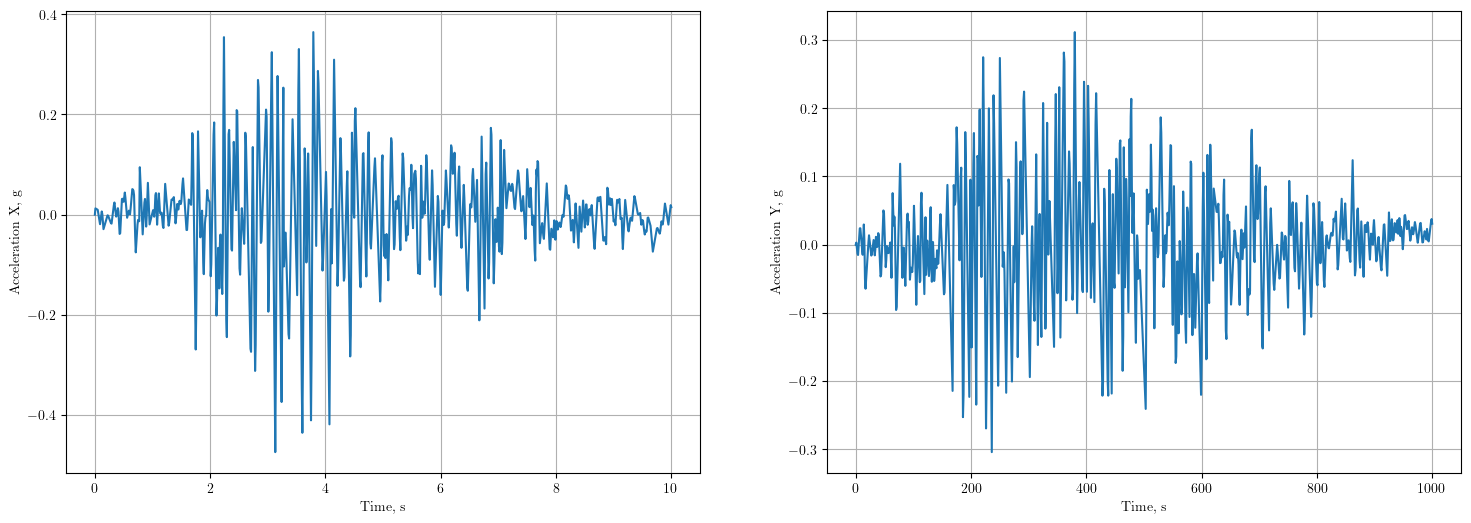

In [10]:
def parse_accelerogram(path: Path, n_values: int = 1001):
    tokens = [
        float(token) for token in re.findall(r"[-+]?\d+\.\d+E[-+]?\d+", path.read_text())
    ]
    values = np.asarray(tokens, dtype=float)
    accelerations = values[1::2]
    if len(accelerations) < n_values:
        raise ValueError(f'{path} contains only {len(accelerations)} acceleration values')
    return accelerations[:n_values]


def write_series_file(path: Path, values):
    path.write_text('\n'.join(f'{float(value):.16e}' for value in values))
    return path


accel_x = parse_accelerogram(KOYNA_DIR / 'data' / 'koyna_x.txt')
accel_y = parse_accelerogram(KOYNA_DIR / 'data' / 'koyna_y.txt')

dt_data = 0.01
n_steps = len(accel_x)-1
duration = n_steps * dt_data
time = np.linspace(0,duration,len(accel_x))
accel_x_path = write_series_file(OUT / 'koyna_x_series.txt', accel_x)
accel_y_path = write_series_file(OUT / 'koyna_y_series.txt', accel_y)

print(f'Input duration: {duration:.3f} s')
print(f'Data time step: {dt_data:.3f} s')

fig, ax = plt.subplots(1,2,figsize=(18, 6))
ax[0].plot(time,accel_x)
ax[0].set_xlabel('Time, s')
ax[0].set_ylabel('Acceleration X, g')
ax[0].grid()
ax[1].plot(accel_y);
ax[1].set_xlabel('Time, s')
ax[1].set_ylabel('Acceleration Y, g')
ax[1].grid()

The following cell uses the [tqdm](https://tqdm.github.io/) package to print a progress bar. 
If the import fails, the package can be installed by running:

```shell
python -m pip install tqdm
```

In [11]:
from tqdm import tqdm
model.wipeAnalysis()


model.timeSeries('Path', 11, dt=dt_data, values=accel_x, factor=g)
model.timeSeries('Path', 12, dt=dt_data, values=accel_y, factor=g)

model.pattern("UniformExcitation", 11, 1, accel=11)
model.pattern("UniformExcitation", 12, 2, accel=12)

model.constraints('Plain')
model.numberer('RCM')
model.system('UmfPack')
model.test('EnergyIncr', 1.0e-12, 3)
model.algorithm('Newton')
model.integrator('Newmark', 0.5, 0.25)
model.analysis('Transient')

dt = 0.005

crest_disp=[model.nodeDisp(crest,1)]
#crest_acc=[model.nodeAccel(crest,1)]

steps = int(duration/dt)
for i in tqdm(range(steps)):
    status = model.analyze(1, dt)
    if status != xara.successful:
            raise RuntimeError(f"analysis failed at time {model.getTime()}")
    crest_disp.append(model.nodeDisp(crest,1))
    #crest_acc.append(model.nodeAccel(crest,1))



100%|██████████| 2000/2000 [00:34<00:00, 58.59it/s]


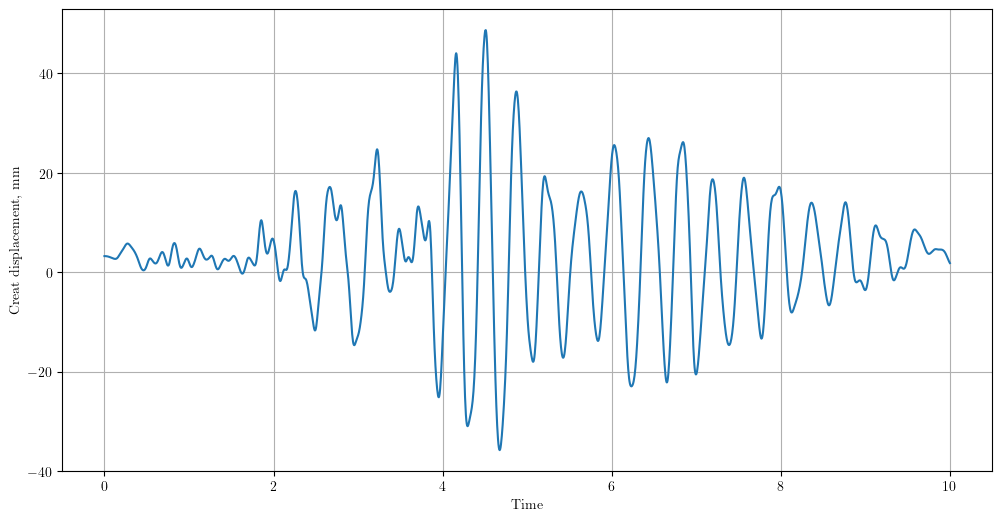

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(np.linspace(0,model.getTime(),len(crest_disp)),np.array(crest_disp)/mm)
ax.set_xlabel('Time')
ax.set_ylabel('Creat displacement, mm')
ax.grid(True)

In [13]:
M = model.getTangent(m=1, c=0, k=0)
np.sum(M)

np.float64(23434531.788900394)